### $\text{Data Loading}$

In [121]:
import pandas as pd

df = pd.read_csv("C:/Python Programming/idr2usd-exchange-rate/data/raw/idr2usd-exchange-rate.csv")
df

,Tahun,USD,JPY,DEM,NLG,GBP,FRH,CHF,SGD,MYR,HKD,AUD,CAD
0,2026,0,0,0,0,0,0,0,0,0,0,0,0
1,Mei,"17,789.00","11,174.00",0,0,"23,970.70",0,"22,677.05","13,924.31","4,485.40","2,270.21","12,743.16","12,885.92"
2,April,"17,324.00","10,850.00",0,0,"23,397.00",2,"21,953.00","13,565.00","4,385.00","2,211.00","12,409.00","12,663.00"
3,Maret,"16,993.00","10,635.00",0,0,"22,508.00",1,"21,245.00","13,182.00","4,216.00","2,169.00","11,642.00","12,217.00"
4,Februari,"16,758.00","10,739.00",0,0,"22,701.00",0,"21,713.00","13,270.00","4,311.00","2,142.00","11,937.00","12,267.00"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
331,2000,"9,595.00","8,357.00","4,557.00","4,044.00","14,299.00","1,359.00","5,860.00","5,539.00","2,525.00","5,319.00",460,"6,389.00"
332,1999,"7,100.00","6,947.00","3,655.00","3,243.00","11,495.00","1,090.00","4,450.00","4,260.00","1,868.00","4,622.00",369,"4,886.00"
333,1998,"8,025.00","7,000.00","4,777.00","4,240.00","13,336.00","1,424.00","5,807.00","4,836.00","2,112.00","4,923.00",482,"5,182.00"
334,1997,"4,650.00","3,578.00","2,598.00","2,306.00","7,709.00",776,"3,197.00","2,773.00","1,198.00","3,040.00",264,"3,247.00"


### $\text{Data Preprocessing}$

In [122]:
import numpy as np

# List of the names of the months in Indonesian
bulan_list = [
    'Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni',
    'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember'
]

# Identify the row containing the year (4 digits)
mask_tahun = df['Tahun'].astype(str).str.fullmatch(r'\d{4}')

# Buat kolom tahun sementara dan isi ke bawah (forward fill)
df['tahun_tmp'] = np.where(mask_tahun, df['Tahun'], np.nan)
df['tahun_tmp'] = df['tahun_tmp'].ffill()

# Create a temporary year column and forward-fill it
df_usd = df[df['Tahun'].isin(bulan_list)].copy()

# Combine the month and year
df_usd['Bulan'] = (
    df_usd['Tahun'] + ' ' +
    df_usd['tahun_tmp'].astype(int).astype(str)
)

# Select only the Month and USD columns
df_usd = df_usd[['Bulan', 'USD']]

# Convert USD to float
df_usd['USD'] = (
    df_usd['USD']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# Reset index to start from 0
df_usd = df_usd.reset_index(drop=True)

# Add a descending index column at the far left
df_usd.insert(0, 'Index', range(len(df_usd), 0, -1))

# Show results
df_usd

,Index,Bulan,USD
0,305,Mei 2026,17789.0
1,304,April 2026,17324.0
2,303,Maret 2026,16993.0
3,302,Februari 2026,16758.0
4,301,Januari 2026,16786.0
...,...,...,...
300,5,Mei 2001,11058.0
301,4,April 2001,11675.0
302,3,Maret 2001,10400.0
303,2,Februari 2001,9835.0


### $\text{Exploration}$

In [127]:
df_usd.describe()

,Index,USD
count,305.000000,305.000000
mean,153.000000,11891.557377
std,88.190136,2713.415219
min,1.000000,8279.000000
25%,77.000000,9230.000000
50%,153.000000,11591.000000
75%,229.000000,14307.000000
max,305.000000,17789.000000


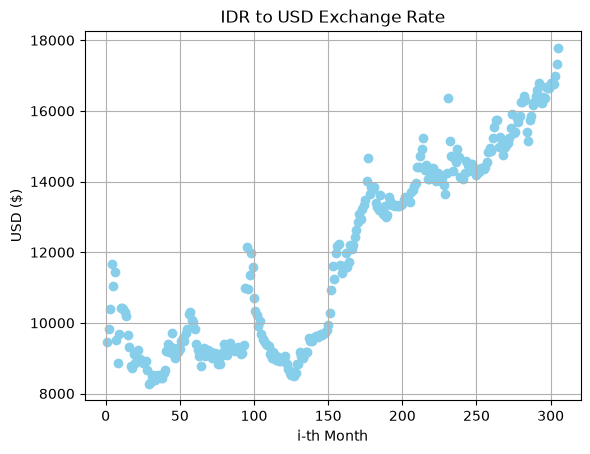

In [126]:
import matplotlib.pyplot as plt

plt.scatter(df_usd['Index'], df_usd['USD'], color='skyblue')
plt.title('IDR to USD Exchange Rate')
plt.xlabel('i-th Month')
plt.ylabel('USD ($)')
plt.grid()
plt.show()

### $\text{Save the Data Preprocessing}$

In [116]:
df_usd.to_csv('C:/Python Programming/idr2usd-exchange-rate/data/processed/idr2usd-exchange-rate-processed.csv')

In [112]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3)
poly_feature = poly.fit_transform(df_usd[['Index']])

X_train, X_test, y_train, y_test = train_test_split(
    poly_feature, df_usd['USD'], test_size=0.2, random_state=42
)

In [113]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0. ,-48.56, 0.49, -0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.027e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[1.27e+08,7.20e+04,1.37e+02,0.00e+00]"


In [114]:
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error

y_pred = model.predict(X_test)

print(f'R2 Score: {r2_score(y_test, y_pred)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred)}')

R2 Score: 0.9408474205399315
MAE: 530.6561518479169
MSE: 434576.4575696172
RMSE: 659.2241330303505
